# Logistic Regression

## Step: Import Libraries

**English:** We import the tools we need: `pandas`/`numpy` for handling data, `matplotlib`/`seaborn` for plotting graphs, and `LogisticRegression` for building our model.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
              
from sklearn.linear_model import LogisticRegression                                                        

## Step: Load the Dataset

**English:** We load the built-in Titanic dataset from seaborn and look at the first 5 rows to see what the data looks like.

In [2]:
titanic=sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step: Statistical Summary

**English:** `.describe()` shows basic statistics (mean, min, max, quartiles) for all numeric columns — helps spot the general range and scale of the data.


In [3]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step: Check Missing Values

**English:** `.isnull().sum()` counts how many missing (NaN) values are in each column. This tells us which columns need cleaning.


In [4]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Step: Missing Percentage — `age`

**English:** We calculate what percentage of the `age` column is missing, to decide whether to fill it or drop it.


In [5]:
titanic.isnull().sum()['age']/titanic.shape[0]

np.float64(0.19865319865319866)

## Step: Missing Percentage — `deck`

**English:** Same check for the `deck` column — this shows it's missing a huge portion, so it's a candidate to drop later.

In [6]:
titanic.isnull().sum()['deck']/titanic.shape[0]


np.float64(0.7721661054994389)

## Step: Visualize Missing Data

**English:** A heatmap of `.isnull()` gives a visual picture of where missing values are located across the whole dataset (yellow lines = missing).


<Axes: >

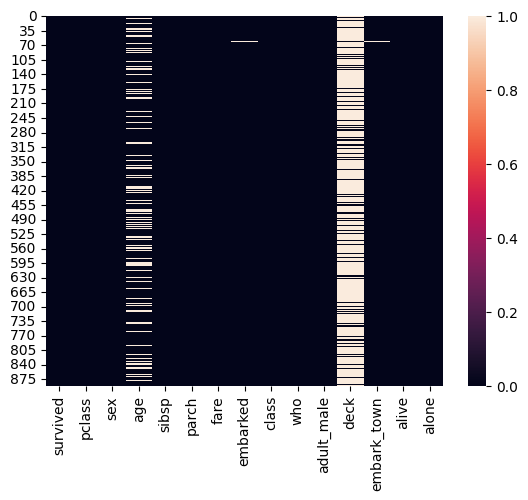

In [7]:
sns.heatmap(titanic.isnull())

## Step: Age Distribution (Histogram + Density)

**English:** We plot the distribution of passenger `age` to understand its shape (e.g. is it normal, skewed, concentrated around a certain range?).


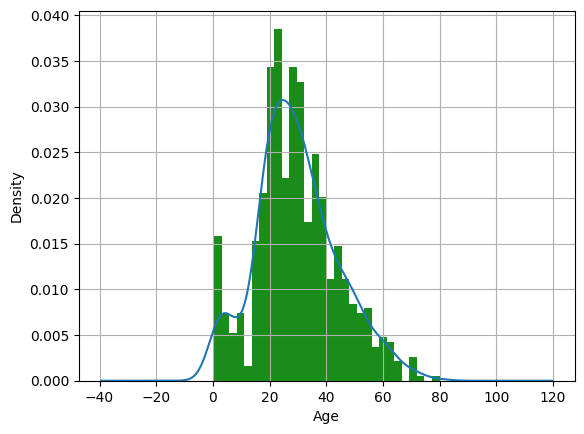

In [8]:
ax=titanic['age'].hist(bins=30,color='green',grid=False,alpha=0.9,density=True)

titanic['age'].plot(kind='density')
plt.xlabel("Age")
plt.ylabel("Density")
plt.grid()

## Step: Age Distribution by Survival and Gender

**English:** This plot breaks down age distribution by `survived` status and `sex`, helping us see if age + gender relate to survival chances.


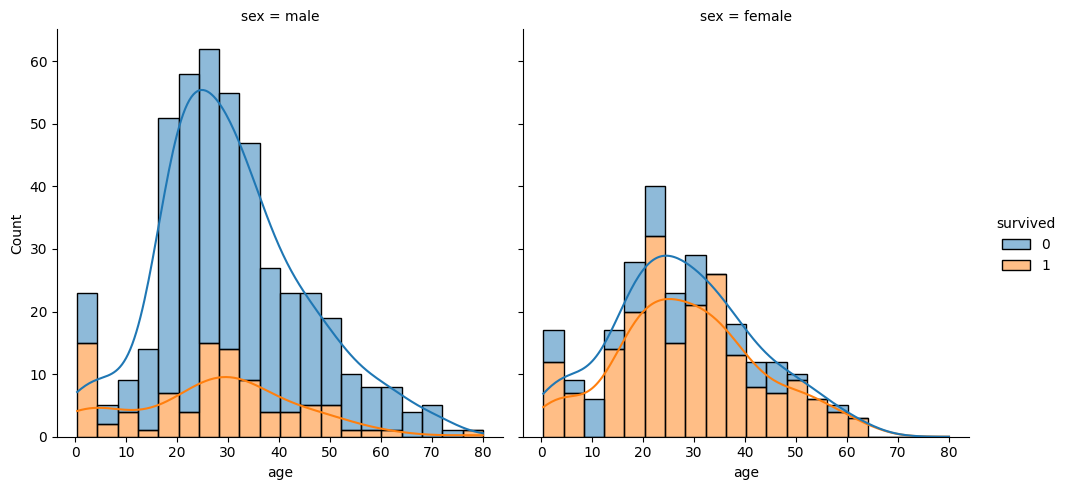

In [9]:
sns.displot(data=titanic,x='age',kde=True,hue='survived',multiple='stack',col='sex')

## Step: Count of Each Gender

**English:** Simple count of how many male vs female passengers are in the dataset.


In [10]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

## Step: Survivors by Gender

**English:** Count of male vs female passengers who survived (`survived == 1`) — a first look at whether gender affected survival.


In [11]:
titanic[titanic['survived']==1]['sex'].value_counts()

sex
female    233
male      109
Name: count, dtype: int64

## Step: Survival Rate by Gender

**English:** We manually calculate the survival rate for females (233/314) vs males (109/577) — females had a much higher survival rate.


In [12]:
233/314,109/577

(0.7420382165605095, 0.18890814558058924)

## Step: Overall Average Age

**English:** The mean age of all passengers — useful as a rough reference before we do smarter (group-wise) imputation.


In [13]:
titanic['age'].mean()

np.float64(29.69911764705882)

## Step: Average Age — Males

**English:** Mean age of male passengers only.

**Roman Urdu:** Sirf male passengers ki average age.

In [14]:
titanic[titanic['sex']=="male"]['age'].mean()

np.float64(30.72664459161148)

## Step: Average Age — Females

**English:** Mean age of female passengers only. Comparing this with the male average shows age differs by gender, which is why we'll use gender (and class) when filling missing ages.

**Roman Urdu:** Sirf female passengers ki average age. Male average se compare karne par pata chalta hai ke age gender ke hisab se farq hai, is liye missing age fill karte waqt gender (aur class) ka istemal karenge.

In [15]:
titanic[titanic['sex']=="female"]['age'].mean()


np.float64(27.915708812260537)

## Step: Age by Passenger Class and Gender (Boxplot)

**English:** A boxplot showing how age varies across `pclass` (1st/2nd/3rd) and `sex`. This confirms that both class and gender affect typical age — the reason we impute missing age using both.


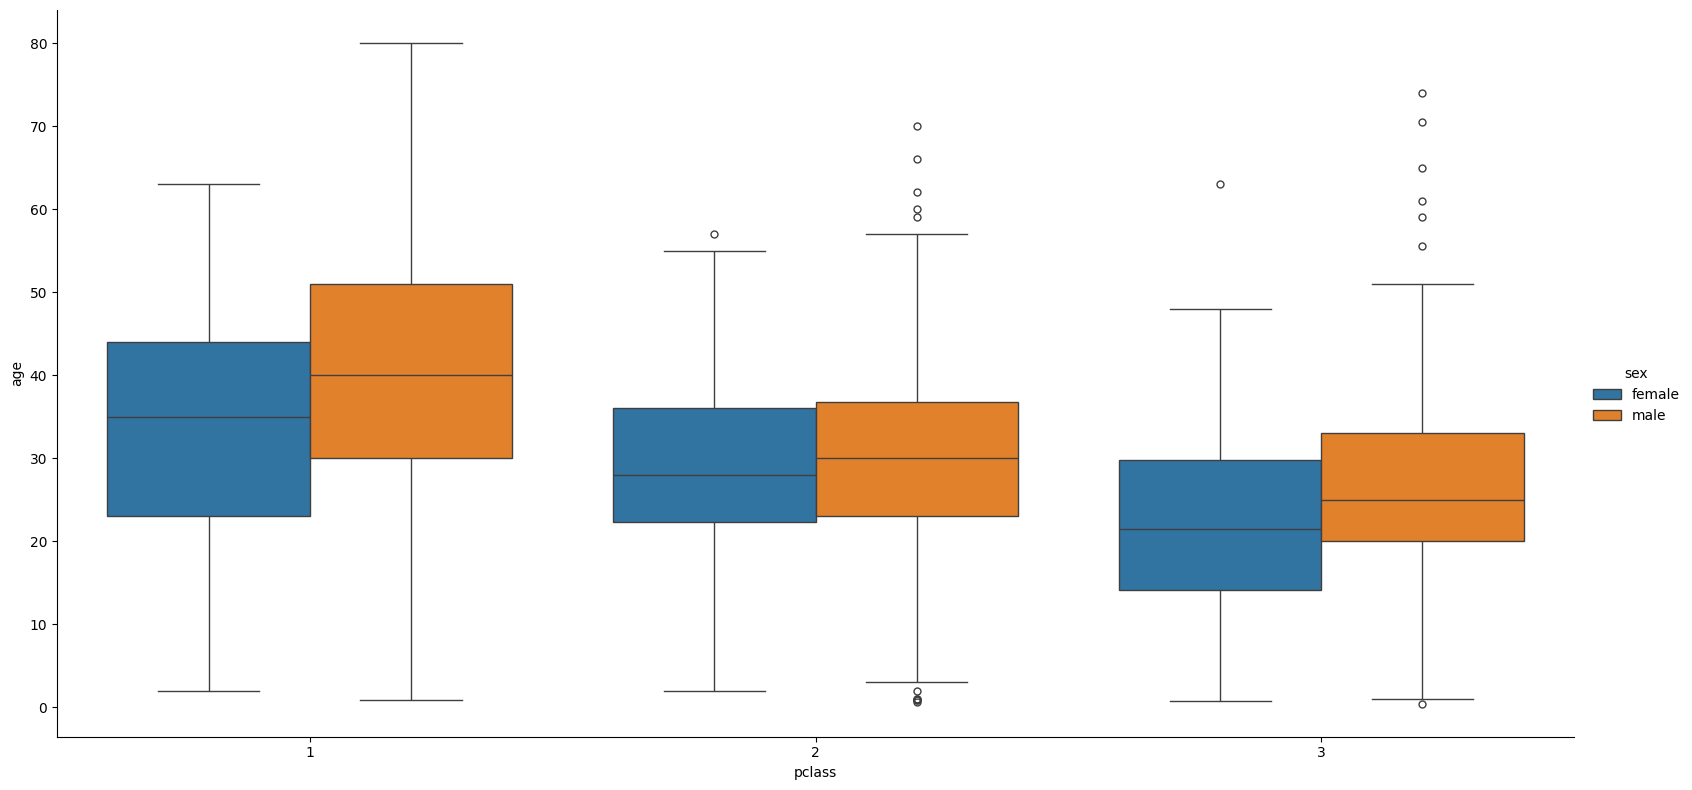

In [16]:

sns.catplot(data=titanic,x='pclass',y='age',kind='box',height=8,aspect=2,hue='sex')


## Step: Define a Smart Age-Filling Function

**English:** Instead of filling all missing ages with one overall average, we write a function that returns the average age for the passenger's specific `pclass` + `sex` group. This gives a more accurate fill than a single global mean.


In [17]:
def input_age(pclass,sex):
    if sex=='male':
        if pclass==1:
            return titanic[(titanic['pclass']==1)&(titanic['sex']=='male')]['age'].mean()
        
        elif pclass==2:
            return titanic[(titanic['pclass']==2)&(titanic['sex']=='male')]['age'].mean()
        
        elif pclass==3:
            return titanic[(titanic['pclass']==3)&(titanic['sex']=='male')]['age'].mean()
    else:
        if pclass==1:
             return titanic[(titanic['pclass']==1)&(titanic['sex']=='female')]['age'].mean()
                
        elif pclass==2:
            return titanic[(titanic['pclass']==2)&(titanic['sex']=='female')]['age'].mean()
                
        elif pclass==3:
            return titanic[(titanic['pclass']==3)&(titanic['sex']=='female')]['age'].mean()
    

## Step: Apply the Function to Fill Missing Ages

**English:** We apply `input_age()` row by row: if `age` is missing (`NaN`), fill it using the group-wise average; otherwise keep the original value.


In [18]:
titanic['age']=titanic.apply(lambda x:input_age(x['pclass'],x['sex']) if np.isnan(x['age']) else x['age'], axis=1)

## Step: Confirm Age is Fixed

**English:** We re-check missing values — `age` should now show 0 missing, confirming the imputation worked. `embarked` (2) and `deck` (688) are still pending, which we handle next.


In [19]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Step 1: Drop `deck` Column (Bohat Zyada Missing Values)

**English:** The `deck` column has ~77% missing values, so it is not useful for modeling. We drop it.


In [20]:
titanic.drop('deck', axis=1, inplace=True)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Step 2: Fill Missing `embarked` Values

**English:** Only 2 rows have missing `embarked`. We fill them with the most frequent value (mode), since it's a categorical column with very few missing entries.


In [21]:
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Step 3: Drop Redundant / Data Leakage Columns

**English:** Some columns are duplicates of others or directly leak the target:
- `alive` is just `survived` written as yes/no → **data leakage**, must drop.
- `who` and `adult_male` are derived from `age` + `sex` (redundant).
- `class` is the same info as `pclass` (redundant, just text vs number).
- `embark_town` is the same info as `embarked` (redundant).
- `alone` is derived from `sibsp` + `parch` (redundant).


In [22]:
titanic.drop(['alive', 'who', 'adult_male', 'class', 'embark_town', 'alone'], axis=1, inplace=True)
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Step 4: Encode Categorical Variables (`sex`, `embarked`)

**English:** Logistic Regression needs numeric input. `sex` and `embarked` are text (categorical), so we convert them into dummy/indicator variables using one-hot encoding. `drop_first=True` avoids the dummy variable trap (multicollinearity).


In [23]:
sex = pd.get_dummies(titanic['sex'], drop_first=True)
embarked = pd.get_dummies(titanic['embarked'], drop_first=True, prefix='embarked')

titanic = pd.concat([titanic, sex, embarked], axis=1)
titanic.drop(['sex', 'embarked'], axis=1, inplace=True)
titanic.head()

,survived,pclass,age,sibsp,parch,fare,male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Step 5: Define Features (X) and Target (y)

**English:** `survived` is the target variable we want to predict. Everything else becomes our feature set `X`.


In [24]:
X = titanic.drop('survived', axis=1)
y = titanic['survived']
X.head()

,pclass,age,sibsp,parch,fare,male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Step 6: Train-Test Split

**English:** We split the data into training (80%) and testing (20%) sets. The model learns on the training set, and we evaluate it on the unseen test set. `random_state` makes the split reproducible.

**Roman Urdu:** Data ko training (80%) aur testing (20%) mein split karte hain. Model training data se seekhta hai, aur test data (jo usne dekha nahi) par uski performance check karte hain. `random_state` isay reproducible banata hai.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((712, 8), (179, 8))

## Step 7: Train the Logistic Regression Model

**English:** We create a `LogisticRegression` model and fit it on the training data. `max_iter` is increased so the optimizer has enough iterations to converge.

**Roman Urdu:** Hum `LogisticRegression` model banate hain aur usay training data par fit (train) karte hain. `max_iter` badhaya gaya hai taake optimizer ko converge hone ke liye kaafi iterations mil sakein.

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 8: Make Predictions

**English:** Now we use the trained model to predict survival on the test set.

**Roman Urdu:** Ab trained model se test data par predictions nikalte hain.

In [27]:
predictions = model.predict(X_test)
predictions[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

## Step 9: Evaluate the Model

**English:** We check how well the model performed using:
- **Accuracy** — overall percentage of correct predictions.
- **Confusion Matrix** — breakdown of correct/incorrect predictions per class.
- **Classification Report** — precision, recall, and F1-score for each class.

**Roman Urdu:** Model ki performance check karte hain:
- **Accuracy** — kitni percentage predictions sahi hain.
- **Confusion Matrix** — har class ke sahi aur ghalat predictions ki tafseel.
- **Classification Report** — precision, recall, aur F1-score har class ke liye.

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.8212290502793296

Confusion Matrix:
 [[92 13]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



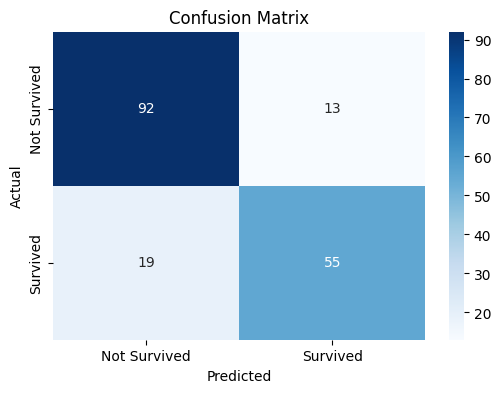

In [29]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived','Survived'], yticklabels=['Not Survived','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Conclusion / Nateeja

**English:** We built a complete Logistic Regression pipeline on the Titanic dataset: explored the data, handled missing values (age via group-wise mean, embarked via mode, dropped deck), removed redundant/leakage columns, encoded categorical variables, split the data, trained the model, and evaluated it with accuracy, confusion matrix, and classification report.
